In [1]:
import os
import netCDF4
import numpy as np
import xarray as xr
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## Plot Profiles

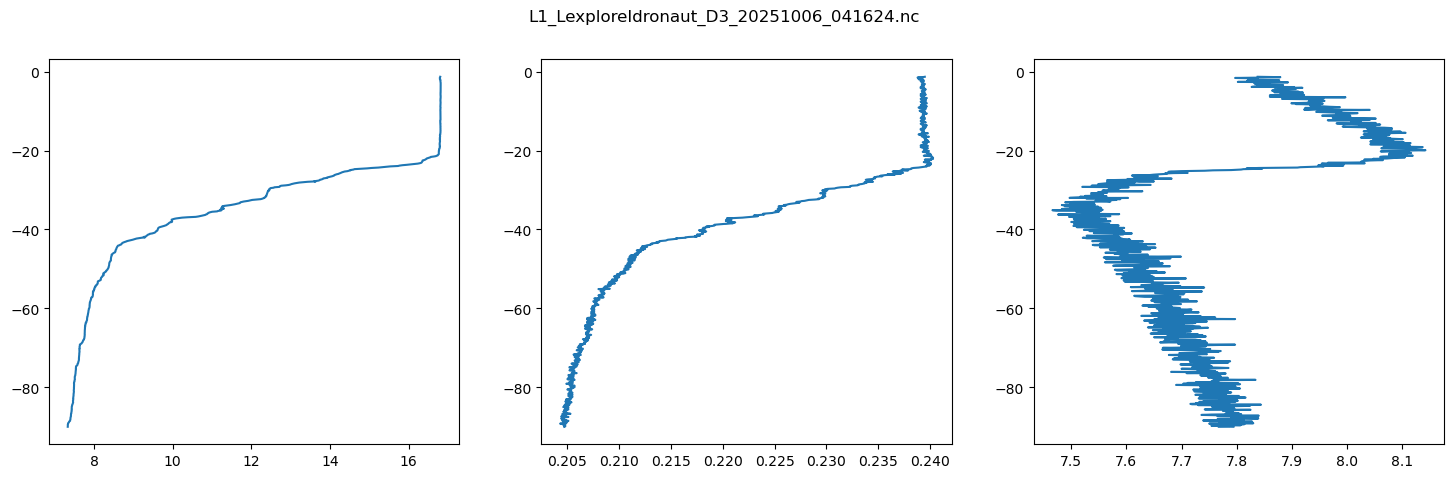

In [14]:
folder = "../data/Level1"
qa = False
files = [os.path.join(folder, f) for f in os.listdir(folder)]
files.sort()
files = files[-1:]
for file in files:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(os.path.basename(file))
    data = {}
    with xr.open_dataset(file, decode_times=False) as ds:
        d = np.array(ds.variables["Press"][:].values)
        for var in ["Temp", "Cond", "pH"]:
            v = np.array(ds.variables[var][:].values)
            if var + "_qual" in ds.variables and qa:
                q = np.array(ds.variables[var + "_qual"][:].values)
                v[q > 0] = np.nan
            data[var] = v
        ax1.plot(data["Temp"], -d)
        ax2.plot(data["Cond"], -d)
        ax3.plot(data["pH"], -d)
    plt.show()

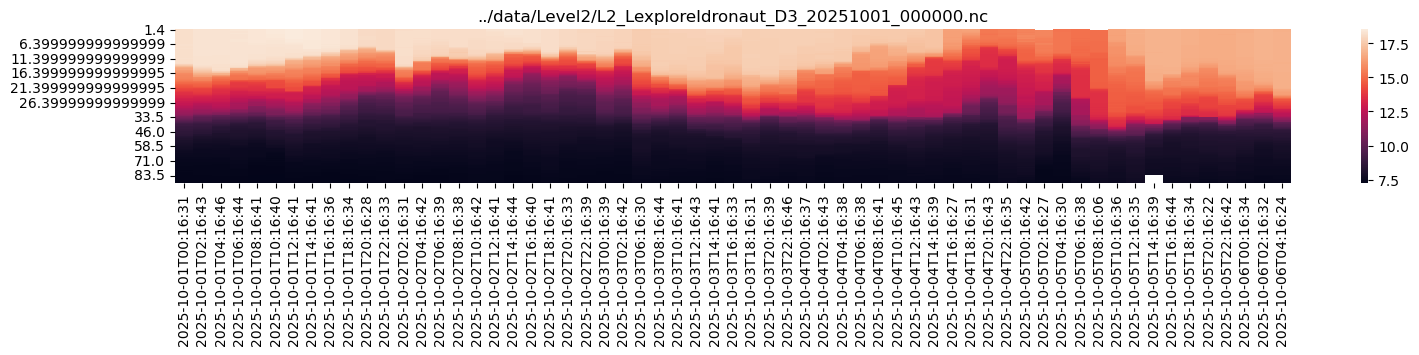

In [5]:
folder = "../data/Level2"
qa = True
files = [os.path.join(folder, f) for f in os.listdir(folder)]
files.sort()
files = [files[-1]]
for file in files:
    if ".nc" in file:
        with netCDF4.Dataset(file) as nc:
            d = np.array(nc.variables["depth"][:])
            t = np.array(nc.variables["time"][:], dtype="datetime64[s]")
            v = np.array(nc.variables["Temp"][:])
            plt.figure(figsize=(18, 2))
            plt.title(file)
            df = pd.DataFrame(data=v,index=d, columns=t)
            sns.heatmap(df)
            plt.show()